<div style="background:linear-gradient(135deg,#4F46E5 0%,#7C3AED 55%,#9333EA 100%);padding:30px 34px;border-radius:16px;color:white;margin-bottom:14px"><div style="font-size:12px;letter-spacing:3px;text-transform:uppercase;opacity:.85">INF672 · Machine Learning · Unidad 2 · EP-01</div><h1 style="margin:10px 0 6px;font-size:32px;line-height:1.1">Primer Parcial — Cuaderno de trabajo</h1><p style="margin:0;font-size:15px;opacity:.92">Estudiante: <b>Abdair Coca</b> · 4 ejercicios · 25 pts c/u (12,5 código + 12,5 justificación)</p></div>
**Instrucciones:** desarrollá cada ejercicio en este notebook, ejecutá las celdas y escribí tus respuestas en las celdas de texto marcadas ✍️. Subí el notebook ejecutado a tu repo y enviá el enlace en la plataforma virtual. ⏱️ 2 h.

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

## 🟣 Ejercicio 01 — Una probabilidad de dos maneras: contar y simular (25 pts)
Evento: «sacar **al menos un 6** al tirar dos dados».

**1.** Valor exacto por conteo: enumerá los 36 pares con `itertools.product(range(1,7), repeat=2)`, contá cuántos tienen al menos un 6 y dividí entre 36.

**2.** Estimación por simulación: generá muchas tiradas con `rng.integers(1, 7, size=(N, 2))`, marcá las que tienen algún 6 y calculá la frecuencia relativa.

**3.** Convergencia: repetí con **N = 100, 1 000 y 100 000** y compará cada estimación con el valor exacto en una tablita de error.

**Para entregar:** valor exacto, tres estimaciones y comparación. Respondé: ¿cuál se acercó más y por qué? ¿Qué le pasa a la estimación con pocas tiradas?

In [34]:
# Ej1.1 — Valor exacto por conteo
# TODO: pares = ... | favorables = ... | p_exacta = ...
# print(...)
numero = 6
pares = itertools.product(range(1,7), repeat=2)
favorables = [x for x in pares if numero in x ]
p_exacta = len(favorables)/36
print(p_exacta)

0.3055555555555556


In [44]:
# Ej1.2/1.3 — Simulación con N = 100, 1000, 100000 y tabla de error
# TODO: rng = np.random.default_rng(...) | tiradas = ... | tabla = ...
# print(...)

rng = np.random.default_rng()

Ns = [100, 1000, 100000]
for N in Ns:
    tiradas = rng.integers(1, 7, size=(N,2))
    resultado = np.any(tiradas == 6, axis=1)
    # cantidad = len([x for x in resultado if x == True])
    cantidad = np.sum(resultado)
    fr = cantidad/N
    error = abs(fr - p_exacta)
    print(p_exacta, fr, error)

0.3055555555555556 0.32 0.014444444444444426
0.3055555555555556 0.319 0.013444444444444426
0.3055555555555556 0.30515 0.0004055555555556034


✍️ **Ej1 — interpretación:** ¿cuál N se acercó más y por qué? ¿Qué pasa con pocas tiradas?

*100000 se acercó más porque el efecto del azar se va compensando hacia la probabilidad real; en cambio, con pocas tiradas el resultado es muy volátil, puede dar 0.20 o 0.50.*

## 🟣 Ejercicio 02 — Perfil estadístico por especie y limpieza (25 pts)
**1.** Perfil por especie: cargá Iris con la columna de especie, agrupá con `groupby('species')` y calculá para las cuatro características: media, mediana, desviación estándar y cuartiles (Q1, Q2, Q3). Presentá tabla legible.

**2.** Faltantes: agregá unos pocos `np.nan` (semilla fija), contálos por columna con `df.isna().sum()` e imputá con la **mediana de cada columna por especie**. Explicá por qué mediana y no media.

**3.** Lectura: mirando las medias por especie, indicá qué característica separa mejor y cuál confunde.

**Para entregar:** tabla de estadísticos, conteo de faltantes antes/después y tu lectura. Respondé: ¿por qué una característica con medias muy distintas separa mejor?

In [89]:
# Ej2.1 — Perfil por especie (mean, median, std, Q1, Q2, Q3)
# TODO: df = ... | grupos = df.groupby('species')...
# print(...)
iris = load_iris(as_frame=True)
df = iris.frame
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})
df = df.drop(columns=["target"])
#print(df.head())
#print(df.columns)
#print(iris.target_names)

grupos = df.groupby("species")

media = grupos.median()
mediana = grupos.mean()
desviacion = grupos.std()
q1 = grupos.quantile(0.25)
q2 = grupos.quantile(0.50)
q3 = grupos.quantile(0.75)
print(media)
#print(mediana)
#print(desviacion)
print(q1[["petal length (cm)", "petal width (cm)"]])
print(q3[["petal length (cm)", "petal width (cm)"]])

            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                    5.0               3.4               1.50   
versicolor                5.9               2.8               4.35   
virginica                 6.5               3.0               5.55   

            petal width (cm)  
species                       
setosa                   0.2  
versicolor               1.3  
virginica                2.0  
            petal length (cm)  petal width (cm)
species                                        
setosa                    1.4               0.2
versicolor                4.0               1.2
virginica                 5.1               1.8
            petal length (cm)  petal width (cm)
species                                        
setosa                  1.575               0.3
versicolor              4.600               1.5
virginica               5.875               2.3


In [79]:
# Ej2.2 — Faltantes con semilla fija + imputación por mediana de cada especie
# TODO: df_miss = ... | df_miss.isna().sum() | df_imp = ...
# print(...)
rng = np.random.default_rng(42)

columnas = [     
    "sepal length (cm)",     
    "sepal width (cm)",     
    "petal length (cm)",     
    "petal width (cm)" 
]

# 1. Introducir valores faltantes
for columna in columnas:
    indices = rng.choice(df.index, size=3, replace=False)
    df.loc[indices, columna] = np.nan

print(df.isna().sum())


sepal length (cm)    3
sepal width (cm)     3
petal length (cm)    3
petal width (cm)     3
species              0
dtype: int64


In [ ]:
for columna in columnas:
    medianas = df.groupby("species")[columna].transform("median")
    df[columna] = df[columna].fillna(medianas)

print(df.isna().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


✍️ **Ej2 — interpretación:** característica que separa mejor, la que confunde, por qué mediana > media, por qué medias distintas separan mejor.

*Petal width separa mejor las especies porque presenta diferencias claras entre sus medias 
y una baja dispersión dentro de cada especie. Además, sus rangos entre Q1 y Q3 se superponen menos 
que en otras variables.*
*Si dos especies tienen medias muy parecidas, sus datos tienden a estar centrados en zonas cercanas, así que es más fácil que se mezclen.*
*Una media distinta indica que el “centro” de cada grupo está en un lugar diferente.*

## 🟣 Ejercicio 03 — Tres formas de comparar dos flores, hechas por ti (25 pts)
**1.** Tres funciones propias con solo NumPy para dos vectores `a`, `b`: distancia euclidiana `np.sqrt(np.sum((a-b)**2))`, producto punto `np.sum(a*b)` y similitud coseno `np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))`.

**2.** Elegí **cuatro flores** de Iris: dos de la misma especie y dos de especies distintas. Anotá los índices.

**3.** Aplicá tus funciones a los pares y organizá resultados en tabla.

**Para entregar:** código de las tres funciones + tabla por par. Respondé: ¿misma especie salió más parecida (menor distancia, mayor coseno)? ¿Euclidiana y coseno ordenan igual?

In [90]:
# Ej3.1 — Tres funciones propias (solo NumPy)
def dist_euc(a, b):
    return np.sqrt(np.sum((a-b)**2))

def prod_punto(a, b):
    return np.sum(a*b)

def sim_coseno(a, b):
    return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))

In [95]:
# Ej3.2/3.3 — Cuatro flores + tabla de pares
# TODO: idx = [...] | pares = [...] | tabla = ...
# print(...)
a = df.loc[0, columnas].to_numpy()      #setosa
b = df.loc[1, columnas].to_numpy()      #setosa
c = df.loc[50, columnas].to_numpy()     #versicolor
d = df.loc[100, columnas].to_numpy()    #virginica
#print(a, b, c, d)
print("MISMA ESPECIE")
print("Distancia:", dist_euc(a, b))
print("Producto punto:", prod_punto(a, b))
print("Coseno:", sim_coseno(a, b))

print("\nESPECIES DISTINTAS")
print("Distancia:", dist_euc(c, d))
print("Producto punto:", prod_punto(c, d))
print("Coseno:", sim_coseno(c, d))
#print(df.loc[[0, 1, 50, 100], "species"])


MISMA ESPECIE
Distancia: 0.5385164807134502
Producto punto: 37.489999999999995
Coseno: 0.9985791635040219

ESPECIES DISTINTAS
Distancia: 1.8439088914585773
Producto punto: 86.36000000000001
Coseno: 0.9821368979794304


✍️ **Ej3 — Tu interpretación:** ¿misma especie más parecida? ¿Euclidiana y coseno ordenan igual?

*Una flor será más parecida cuando la distancia sea menor entre sí; también cuando el coseno esté más cerca de uno.*
*En este caso, la distancia y el coseno sí ordenan igual, porque a menor distancia euclidiana será de la misma especie
y a mayor similitud coseno será de la misma especie.*

## 🟣 Ejercicio 04 — Bajar la colina: descenso de gradiente (25 pts)
Función: **f(x) = (x − 4)² + 1**, mínimo en **x = 4**. Derivada dada: **f′(x) = 2·(x − 4)**.

**1.** Programá el descenso: partí de **x = 10**, actualizá `x = x − tasa·f′(x)` un número fijo de pasos, guardá la evolución de x.

**2.** Probá tres tasas: **pequeña (0,01)**, **intermedia (0,1)** y **grande (1,1)**. Graficá la trayectoria de x en cada caso.

**3.** Compará el x final de cada tasa con el mínimo verdadero (x = 4).

**Para entregar:** trayectorias para las tres tasas + comparación con x = 4. Respondé: ¿todas llegan cerca? ¿Tasa chica (lento?) y grande (se pasa, oscila, diverge?)?

In [97]:
# Ej4.1 — Función, derivada y descenso
# TODO: f = ... | derivada = ... | descenso = ...
def f(x):
    return (x - 4)**2 + 1

def derivada(x):
    return 2 * (x - 4)

def descenso(x0, tasa, pasos):
    x = x0
    historia = [x]
    for i in range(pasos):
        x = x - tasa * derivada(x)
        historia.append(x)
    return historia

0.01 7.272905916294624 3.272905916294624
0.1 4.007427640235712 0.007427640235712296
1.1 1428.2578827986254 1424.2578827986254


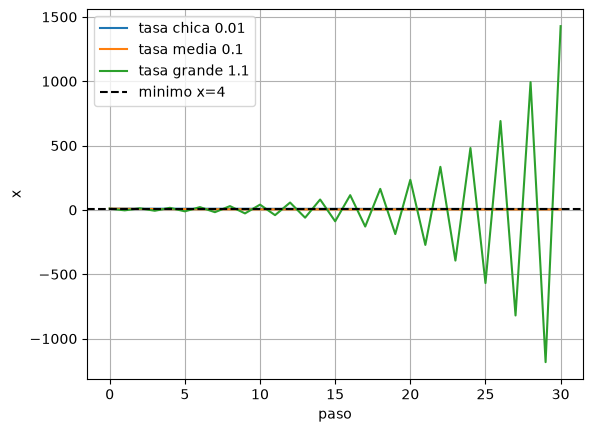

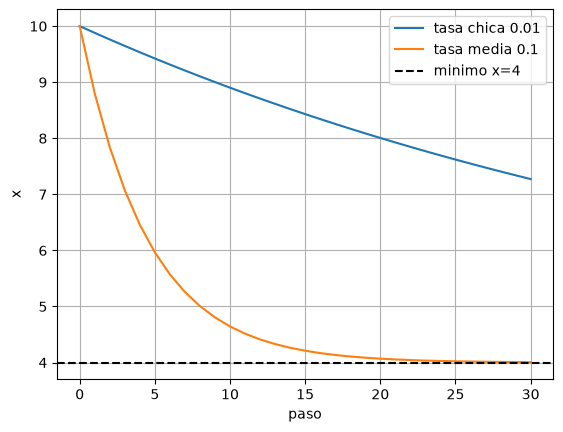

In [99]:
# Ej4.1/4.2 — Descenso de gradiente con 3 tasas + gráfica
# TODO: tasas = ... | historias = ... | plt.plot(...)
# print(...)
inicio = 10
pasos = 30

tasa_chica = 0.01
tasa_media = 0.1
tasa_grande = 1.1

hist_chica = descenso(inicio, tasa_chica, pasos)
hist_media = descenso(inicio, tasa_media, pasos)
hist_grande = descenso(inicio, tasa_grande, pasos)

#print(hist_chica)
#print(hist_media)
#print(hist_grande)

final_chica = hist_chica[-1]
final_media = hist_media[-1]
final_grande = hist_grande[-1]

error_chica = abs(final_chica - 4)
error_media = abs(final_media - 4)
error_grande = abs(final_grande - 4)

print(tasa_chica, final_chica, error_chica)
print(tasa_media, final_media, error_media)
print(tasa_grande, final_grande, error_grande)

plt.figure()
plt.plot(hist_chica, label="tasa chica 0.01")
plt.plot(hist_media, label="tasa media 0.1")
plt.plot(hist_grande, label="tasa grande 1.1")
plt.axhline(4, color="k", linestyle="--", label="minimo x=4")
plt.xlabel("paso")
plt.ylabel("x")
plt.legend()
plt.grid(True)
plt.show()

# Zoom de las tasas que no divergen
plt.figure()
plt.plot(hist_chica, label="tasa chica 0.01")
plt.plot(hist_media, label="tasa media 0.1")
plt.axhline(4, color="k", linestyle="--", label="minimo x=4")
plt.xlabel("paso")
plt.ylabel("x")
plt.legend()
plt.grid(True)
plt.show()

✍️ **Ej4 — Tu interpretación:** ¿todas llegan? ¿Tasa chica vs grande qué pasa?

*No, no todas llegan. Con tasa 0,01 el avance es muy lento y tras 30 pasos queda en x≈7,27, lejos del mínimo x=4. Con tasa 0,1 converge rápido y queda en x≈4,01, prácticamente en el mínimo. Con tasa 1,1 se pasa del mínimo en cada paso, oscila y diverge hasta x≈1428. La tasa chica avanza poco por paso; la grande multiplica el error por |1−2·tasa|>1 y por eso oscila y diverge.*

## ✅ Checklist de entrega
- [ ] Notebook ejecutado de punta a punta sin errores
- [ ] Cada ejercicio con código + tabla/gráfica + justificación ✍️ completa
- [ ] Subido al repo + enlace en plataforma virtual